## IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.mixture import GaussianMixture
import warnings
import os
import joblib

sns.set(font_scale=0.5, style="ticks")
sns.set_context("poster", font_scale=.5, rc={"grid.linewidth": 0.6})
%matplotlib inline

## IMPORT RAW DATA

In [2]:
df = pd.read_csv(r'D:\Đồ án\Recommentation_test\CREDIT_USE_DATA.csv', dtype={'CUS_ID': str})
df_cp = df.copy()

df.head()

,CUS_ID,CREDIT_BALANCE,FREQUENCY_BALANCE_FLUCTUATION,SHOPPING_VALUE,SHOPPING_VALUE_ONE_TIME,INSTALLMENT_PAYMENT_VALUE,SHOPPING_FREQUENCY,SHOPPING_FREQUENCY_ONE_TIME,INSTALLMENT_PAYMENT_FREQUENCY,SHOPPING_NUM,CARD_LIMIT,TOTAL_PAYMENT,MIN_PAYMENT_AMOUNT,PAYMENT_RATIO,TERM,ETL_DATE
0,1000001,1000000.0,0.818182,2375000,0,2375000,0.166667,0.000000,0.083333,2,30000000,5025000,3475000,0.000000,12,20250410
1,1000002,80050000.0,0.909091,161050000,161050000,0,0.250000,0.250000,0.000000,4,180000000,102575000,26800000,0.222222,12,20250410
2,1000003,3865000.0,1.000000,34785000,34785000,0,1.000000,1.000000,0.000000,12,190000000,15550000,1555000,0.000000,12,20250410
3,1000004,41650000.0,0.636364,42600000,37475000,5125000,0.083333,0.083333,0.083333,2,190000000,0,0,0.000000,12,20250410
4,1000005,80000.0,1.000000,720000,720000,0,0.083333,0.083333,0.000000,1,30000000,16950000,6100000,0.000000,12,20250410


## EDA AND PREPOCESSING

In [3]:
df.shape

(8953, 16)

In [4]:
df.describe()


,CREDIT_BALANCE,FREQUENCY_BALANCE_FLUCTUATION,SHOPPING_VALUE,SHOPPING_VALUE_ONE_TIME,INSTALLMENT_PAYMENT_VALUE,SHOPPING_FREQUENCY,SHOPPING_FREQUENCY_ONE_TIME,INSTALLMENT_PAYMENT_FREQUENCY,SHOPPING_NUM,CARD_LIMIT,TOTAL_PAYMENT,MIN_PAYMENT_AMOUNT,PAYMENT_RATIO,TERM,ETL_DATE
count,8.953000e+03,8953.000000,8.953000e+03,8.953000e+03,8.953000e+03,8953.000000,8953.000000,8953.000000,8953.000000,8.953000e+03,8.953000e+03,8.953000e+03,8953.000000,8953.000000,8.953000e+03
mean,2.863854e+07,0.877312,6.397163e+07,4.347808e+07,1.482720e+07,0.552652,0.278134,0.390809,17.957444,1.245054e+08,4.331413e+07,8.865542e+06,0.153797,11.516363,2.025041e+07
std,4.775520e+07,0.236875,8.568216e+07,6.887372e+07,3.119522e+07,0.349861,0.290409,0.387111,25.334202,1.051038e+08,7.236516e+07,1.655903e+07,0.292485,1.339818,3.076444e+00
min,0.000000e+00,0.000000,0.000000e+00,-1.500000e+07,0.000000e+00,0.083333,0.000000,0.000000,0.000000,5.475000e+06,0.000000e+00,0.000000e+00,0.000000,6.000000,2.025041e+07
25%,1.355000e+06,0.888889,1.160000e+07,3.600000e+06,0.000000e+00,0.200000,0.083333,0.000000,4.000000,5.000000e+07,9.575000e+06,1.850000e+06,0.000000,12.000000,2.025041e+07
50%,6.960000e+06,1.000000,3.295000e+07,1.982500e+07,4.525000e+06,0.500000,0.166667,0.250000,10.000000,9.000000e+07,2.142500e+07,4.250000e+06,0.000000,12.000000,2.025041e+07
75%,3.400000e+07,1.000000,7.987500e+07,5.507500e+07,1.577500e+07,0.916667,0.416667,0.750000,21.000000,1.700000e+08,4.757500e+07,9.000000e+06,0.142857,12.000000,2.025041e+07
max,4.760750e+08,1.000000,1.239925e+09,1.181775e+09,5.625000e+08,1.500000,1.500000,1.250000,358.000000,1.410000e+09,1.268025e+09,4.655250e+08,1.000000,12.000000,2.025060e+07


In [5]:
df.isna().sum()

CUS_ID                           0
CREDIT_BALANCE                   0
FREQUENCY_BALANCE_FLUCTUATION    0
SHOPPING_VALUE                   0
SHOPPING_VALUE_ONE_TIME          0
INSTALLMENT_PAYMENT_VALUE        0
SHOPPING_FREQUENCY               0
SHOPPING_FREQUENCY_ONE_TIME      0
INSTALLMENT_PAYMENT_FREQUENCY    0
SHOPPING_NUM                     0
CARD_LIMIT                       0
TOTAL_PAYMENT                    0
MIN_PAYMENT_AMOUNT               0
PAYMENT_RATIO                    0
TERM                             0
ETL_DATE                         0
dtype: int64

In [6]:
df.drop(columns='CUS_ID', inplace=True)

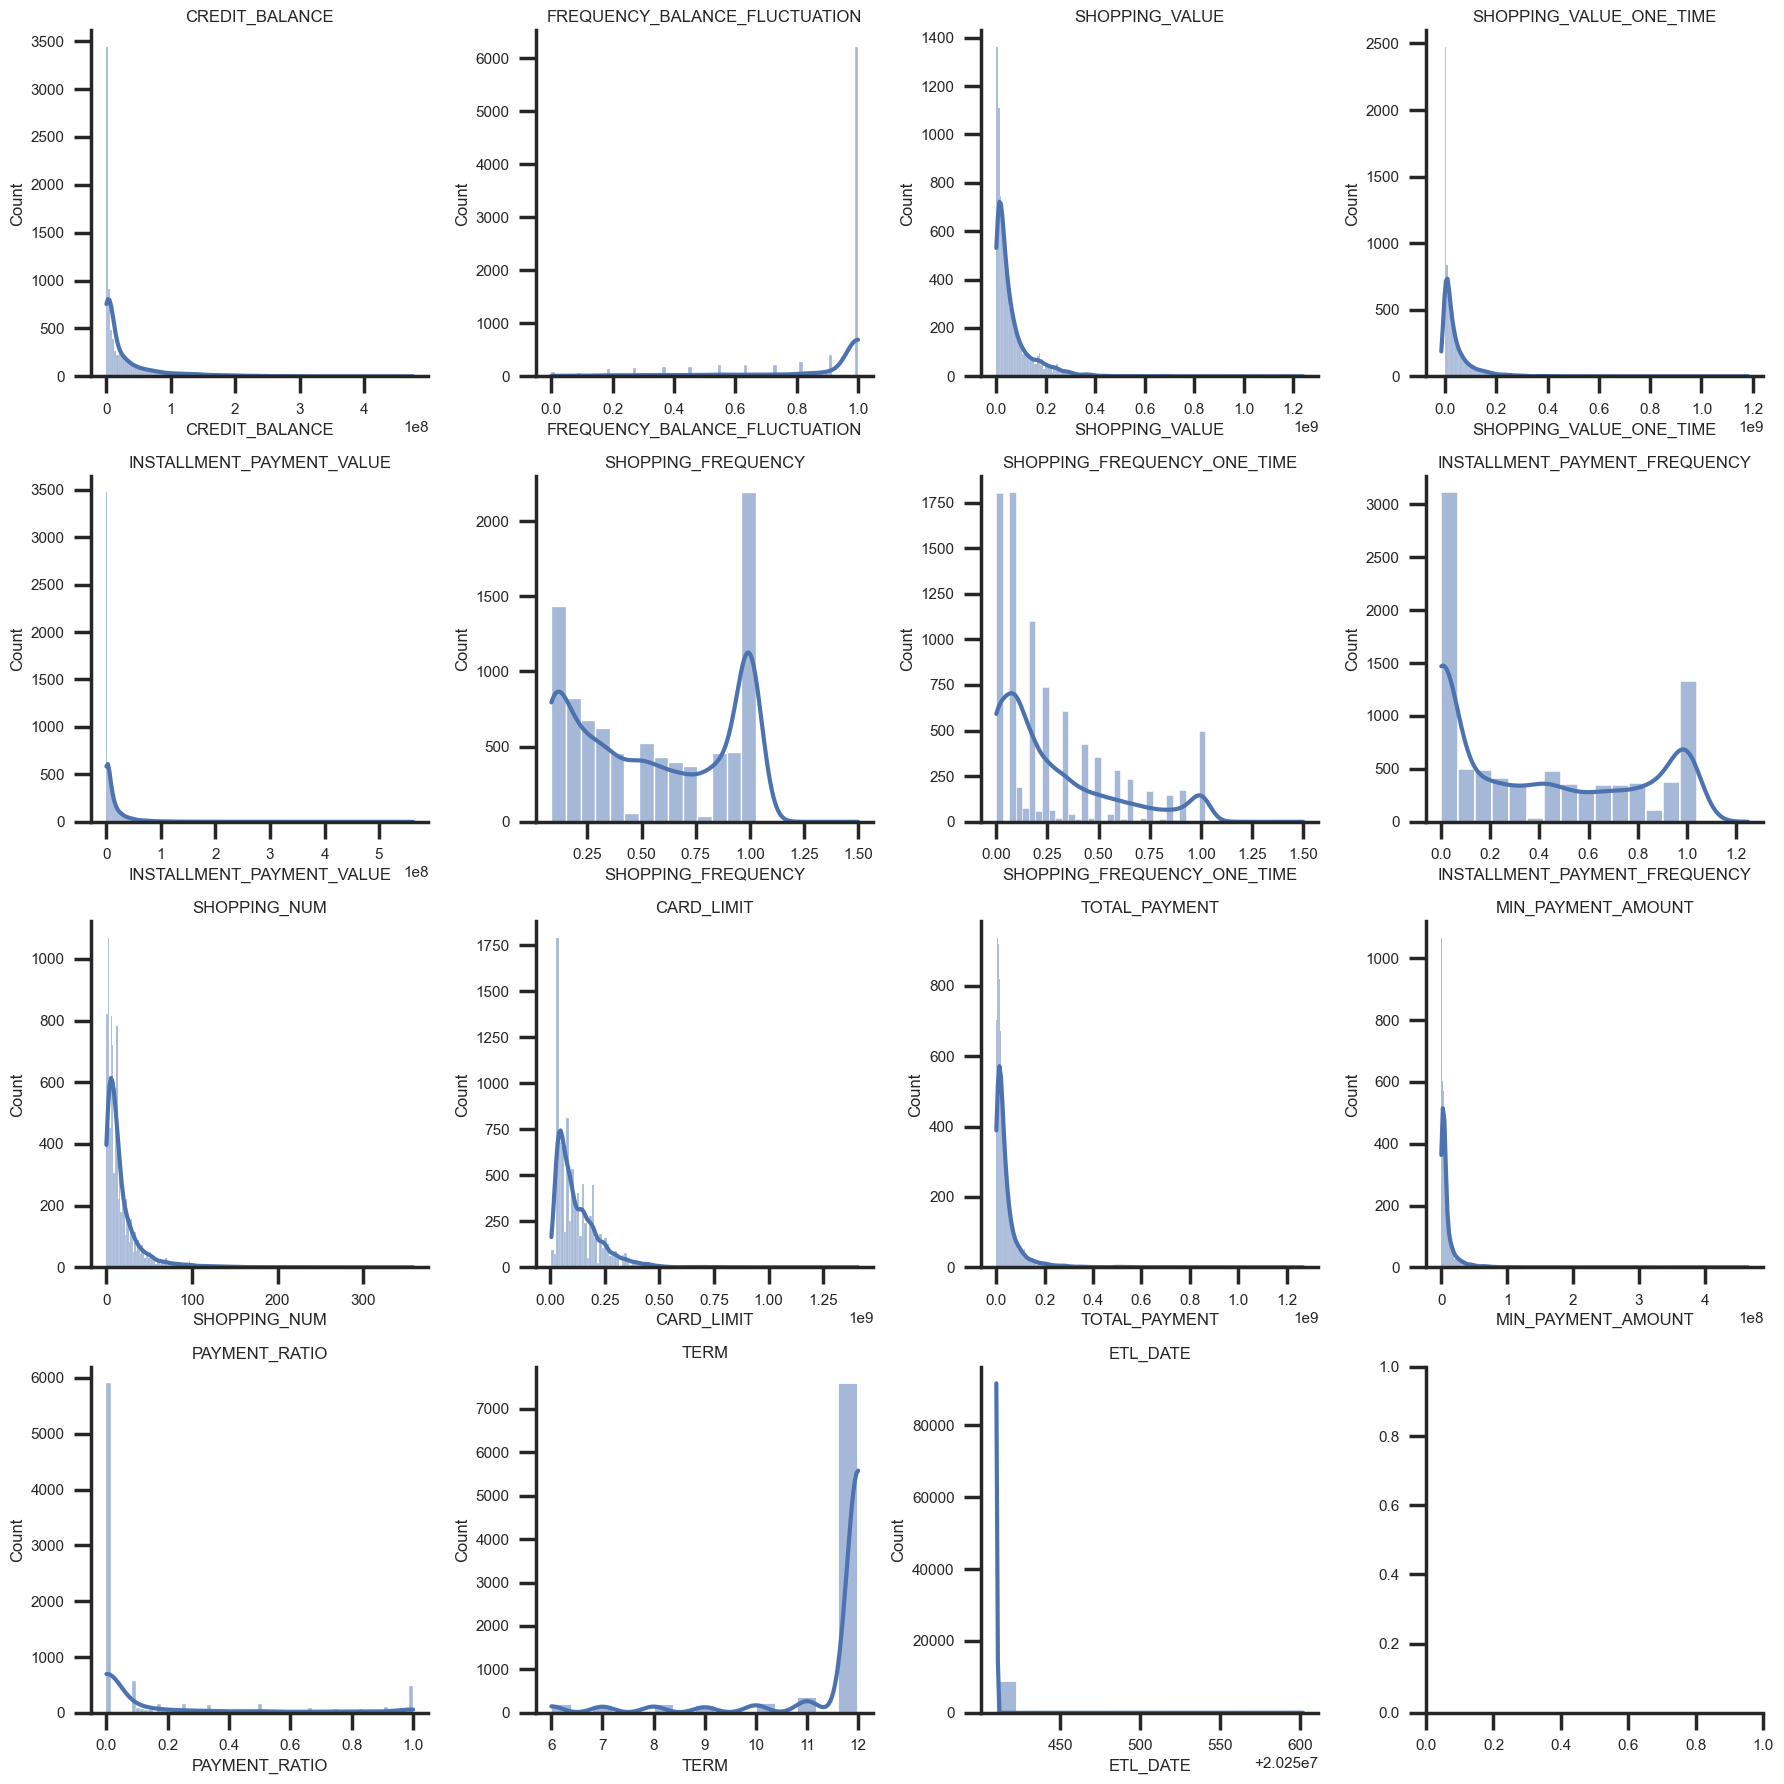

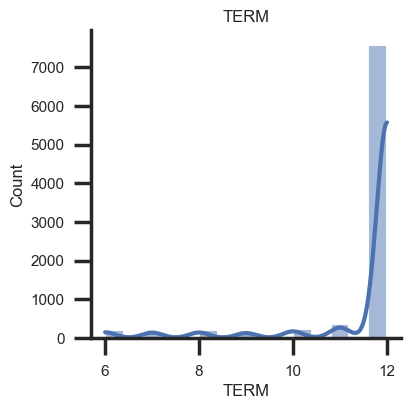

In [7]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(18, 18))

for i in range(4):
    for j in range(4):
        col_index = 4 * i + j
        if col_index < len(df.columns):
            col = df.columns[col_index]
            sns.histplot(df[col], kde=True, ax=axs[i, j])
            axs[i, j].set_title(col)
sns.despine()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
sns.histplot(df["TERM"], kde=True, ax=ax)
ax.set_title("TERM")
sns.despine()
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

selected_cols = [
    "CREDIT_BALANCE",
    "FREQUENCY_BALANCE_FLUCTUATION",
    "SHOPPING_VALUE",
    "SHOPPING_VALUE_ONE_TIME",
    "INSTALLMENT_PAYMENT_VALUE",
    "SHOPPING_FREQUENCY",
    "SHOPPING_FREQUENCY_ONE_TIME",
    "INSTALLMENT_PAYMENT_FREQUENCY",
    "SHOPPING_NUM",
    "CARD_LIMIT",
    "TOTAL_PAYMENT",
    "MIN_PAYMENT_AMOUNT",
    "PAYMENT_RATIO","TERM"
]

df_tmp = df[selected_cols].copy()


scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_tmp)

df_out = pd.DataFrame(scaled_values, columns=selected_cols)

<Axes: >

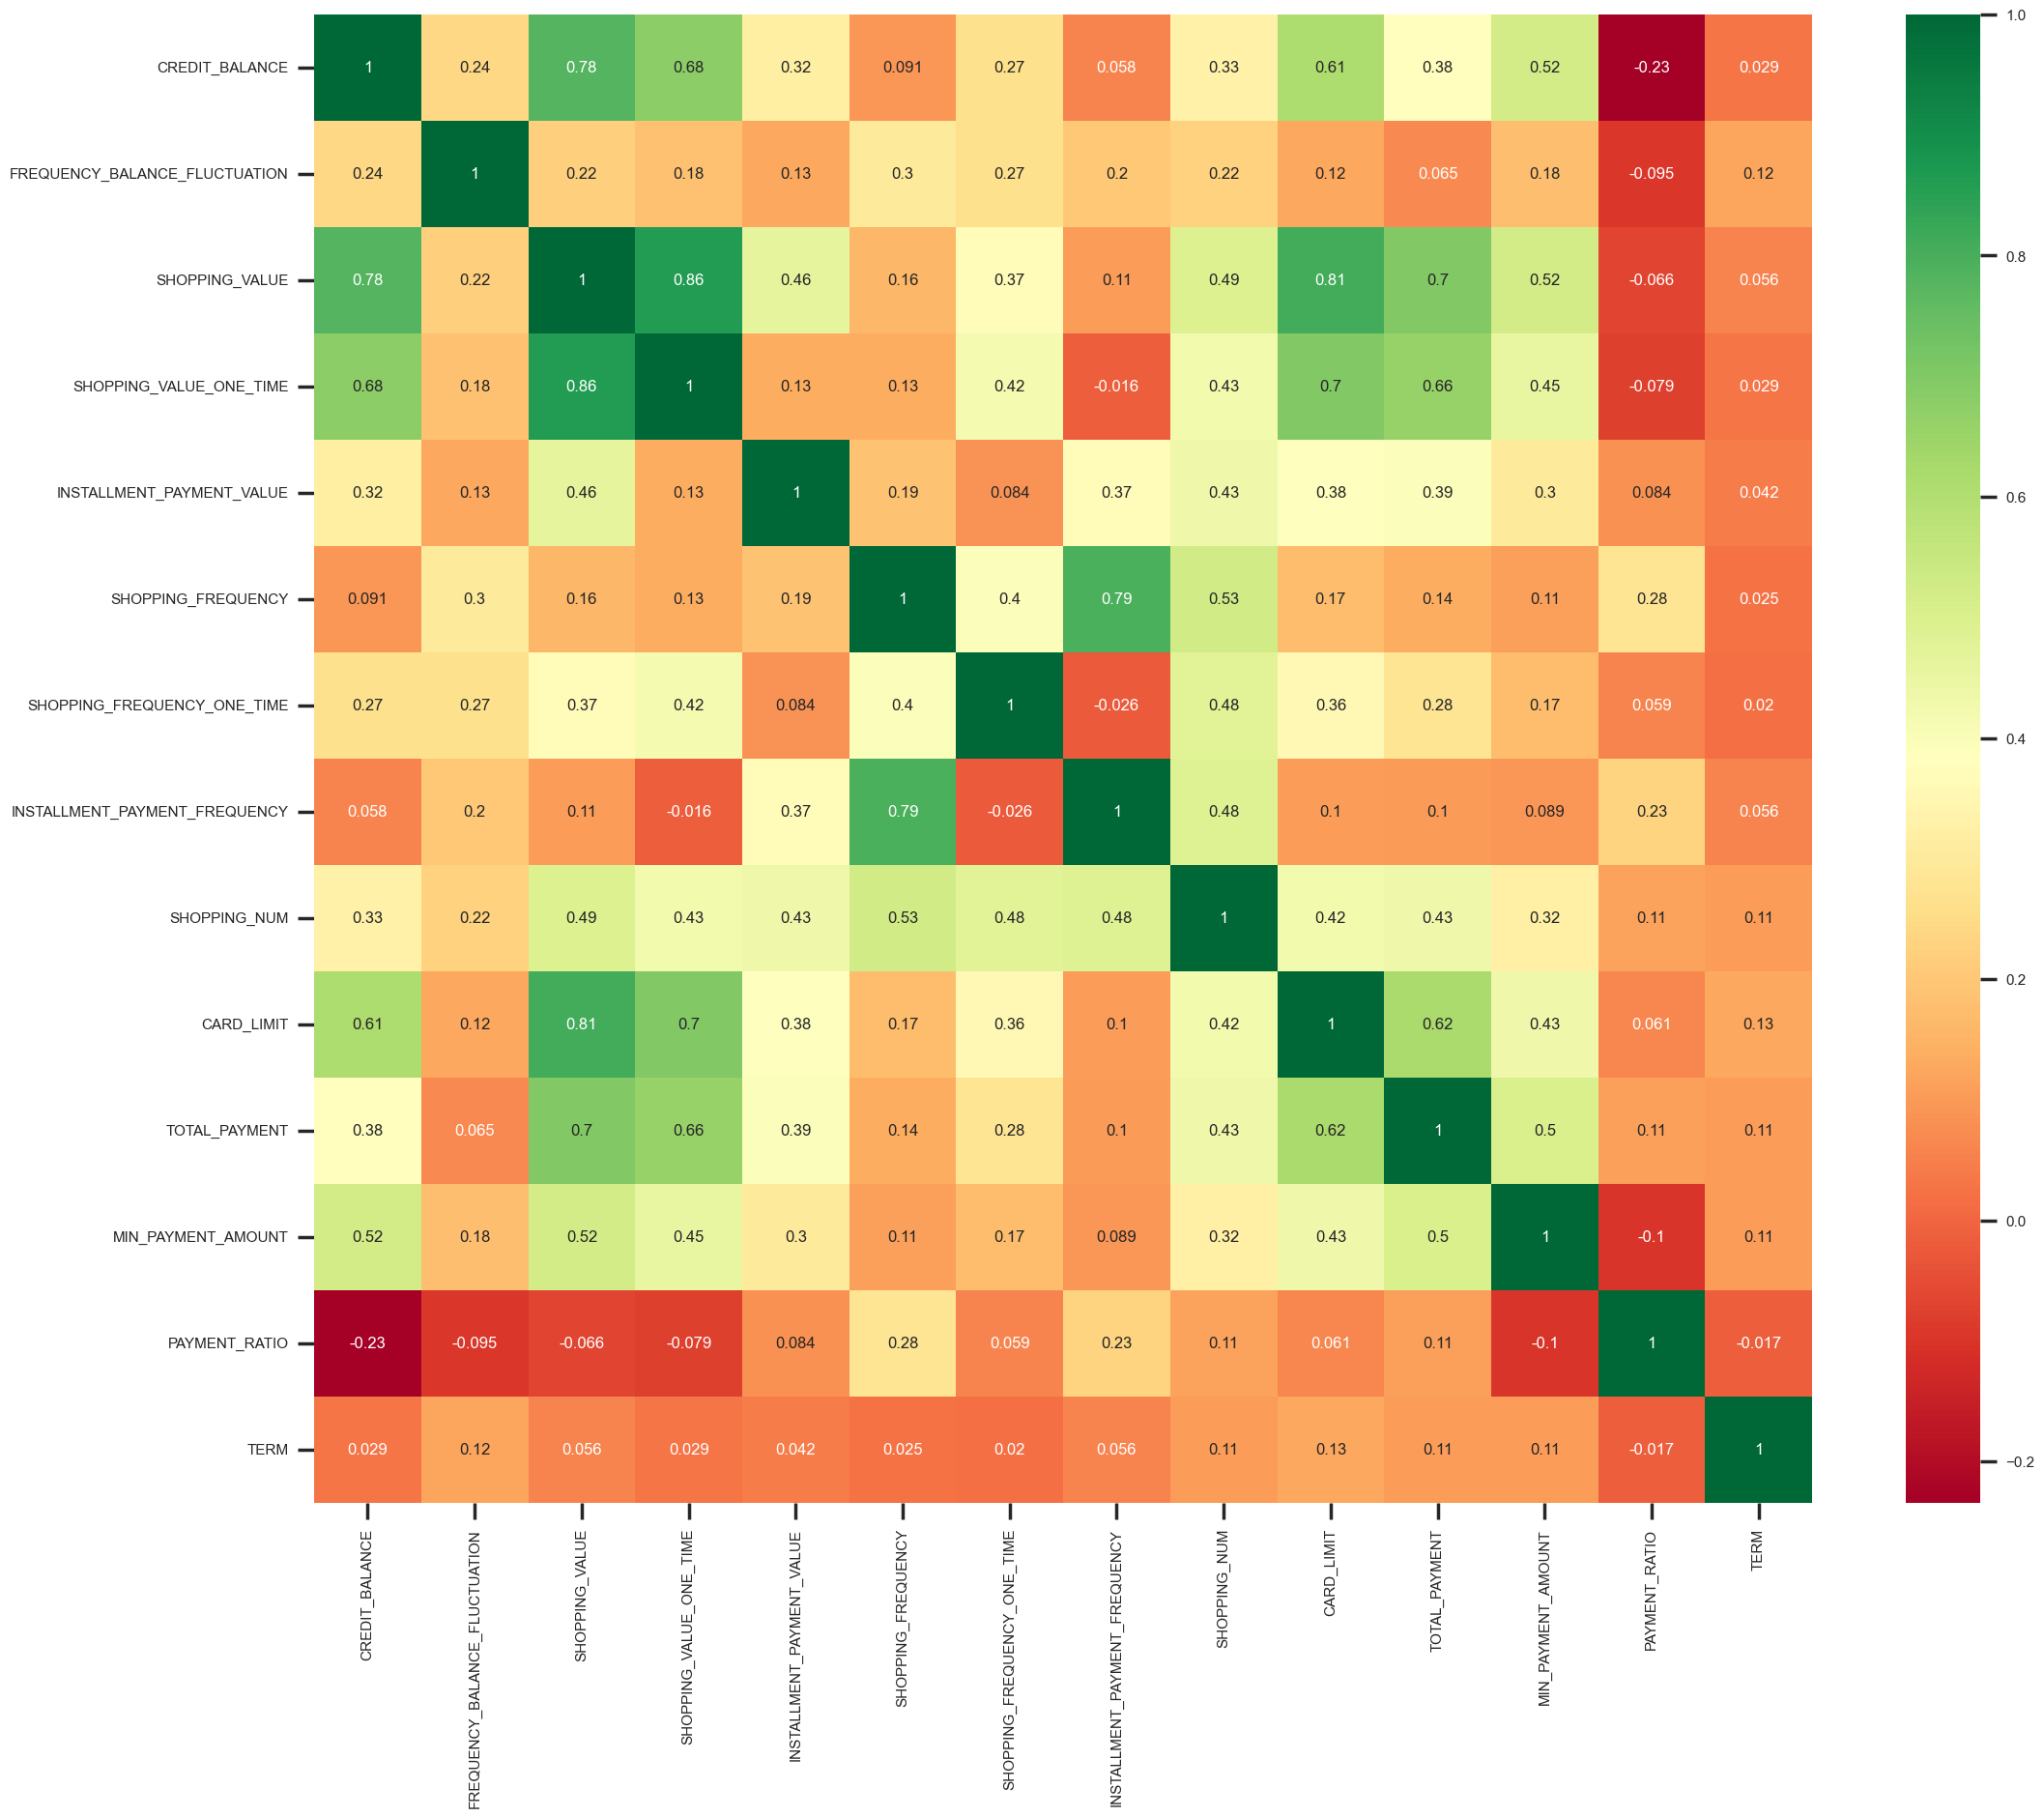

In [9]:
correlations = df_out.corr()
plt.figure(figsize=(25, 20))
sns.heatmap(correlations, annot=True, cmap="RdYlGn")


## USING GMM MOEL AND AIC/BIC CURVE

c:\Users\Surface\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Surface\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Surface\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Users\Surface\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Us

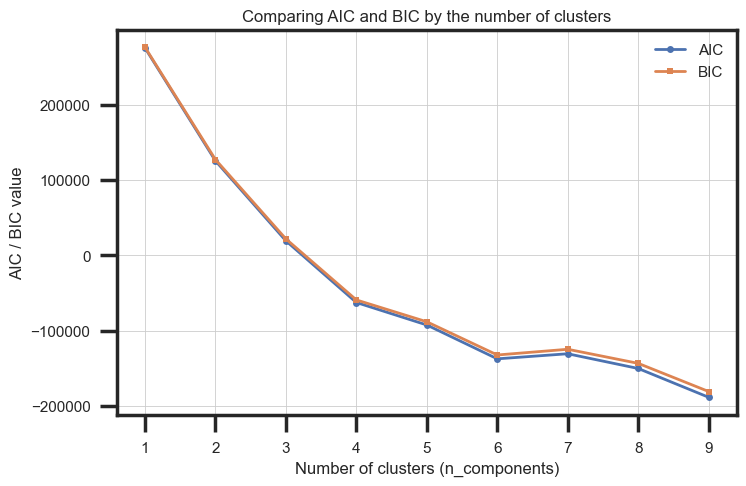

In [10]:
AIC = []
BIC = []

n_components_range = range(1, 10)

for n in n_components_range:
    GMM = GaussianMixture(n_components=n, random_state=00)
    GMM.fit(df_out)

    AIC.append(GMM.aic(df_out))
    BIC.append(GMM.bic(df_out))
    
plt.figure(figsize=(8, 5))
plt.plot(n_components_range, AIC, label='AIC', marker='o', markersize=5, linewidth=2)
plt.plot(n_components_range, BIC, label='BIC', marker='s', markersize=5, linewidth=2)
plt.xlabel('Number of clusters (n_components)')
plt.ylabel('AIC / BIC value')
plt.title('Comparing AIC and BIC by the number of clusters')
plt.legend()
plt.grid(True)
plt.show()

n_components = 6 because of the elbow point

## FIT GMM MODEL

In [11]:
GMM = GaussianMixture(n_components=6, n_init=10, random_state=00)
GMM.fit(df_out)
clusters = GMM.predict(df_out)

In [12]:
df_cp

result_df = pd.concat([df_cp, pd.DataFrame({'SEGMENT': clusters})], axis=1)

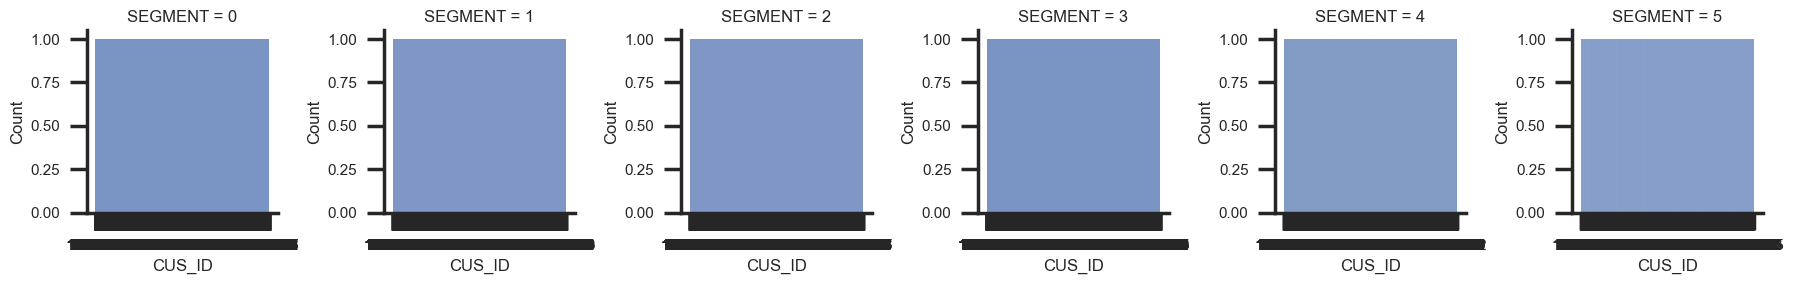

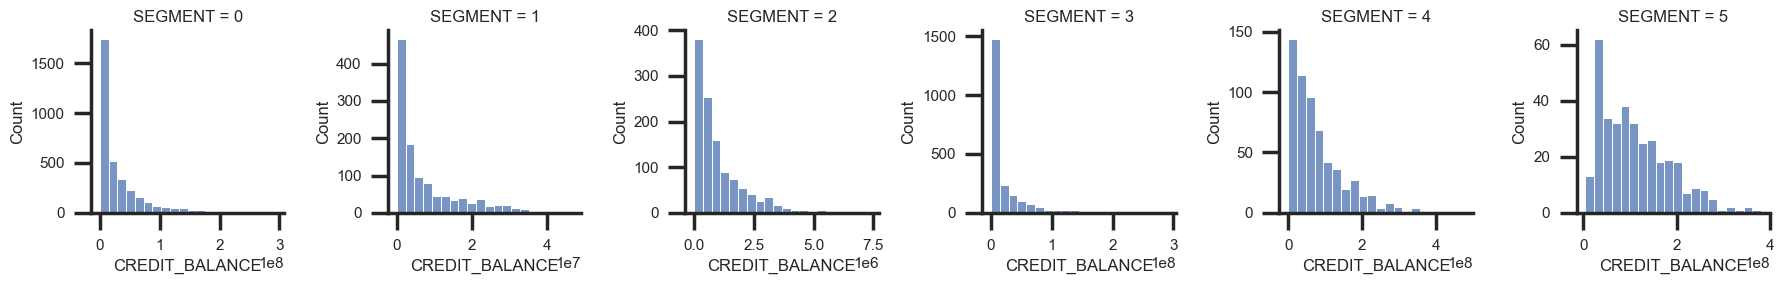

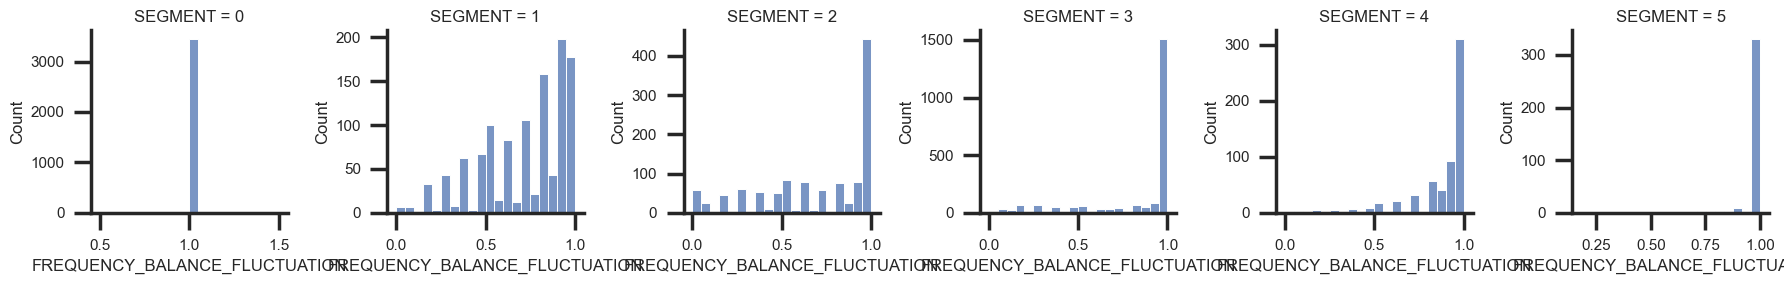

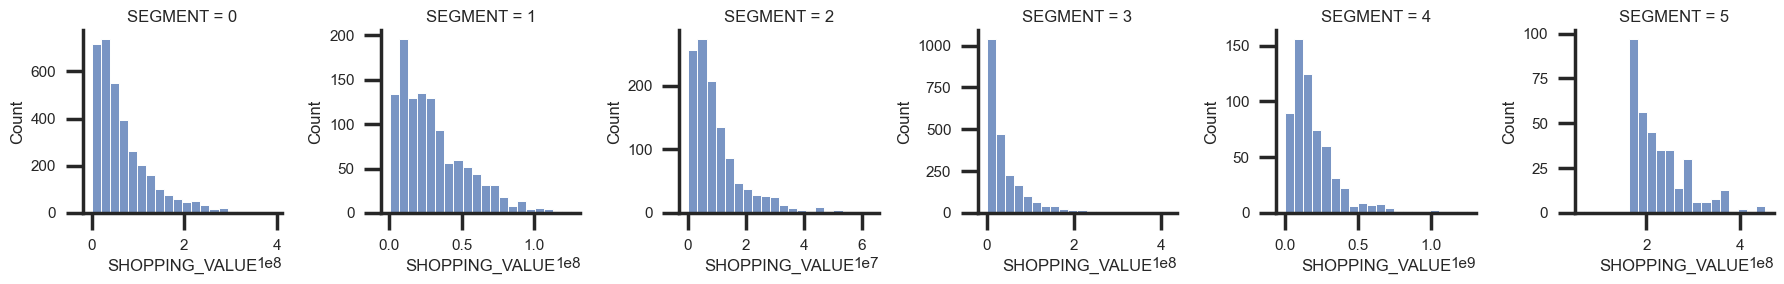

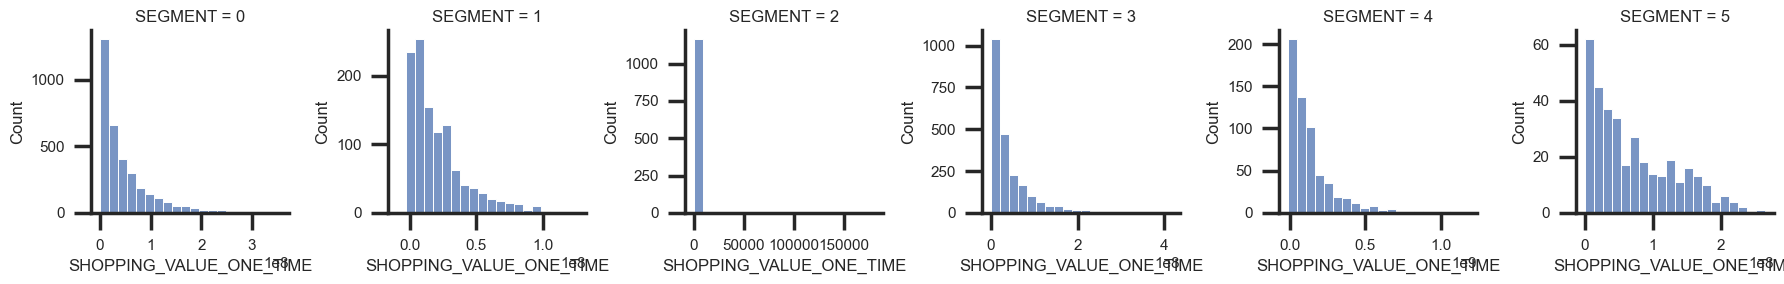

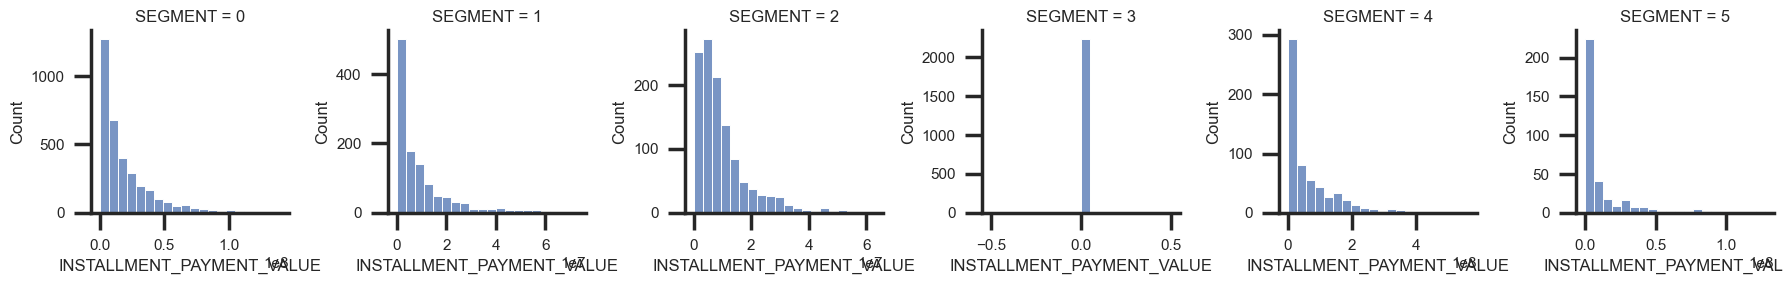

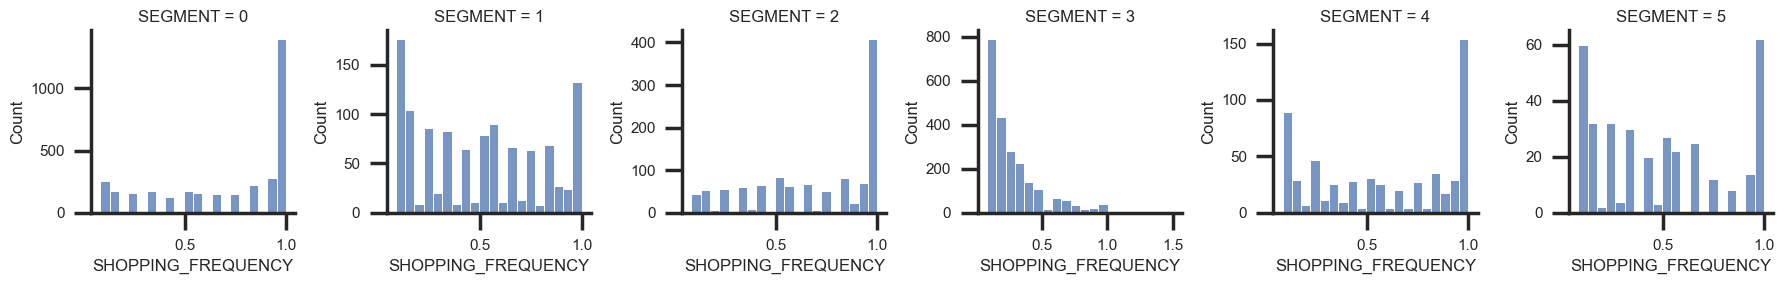

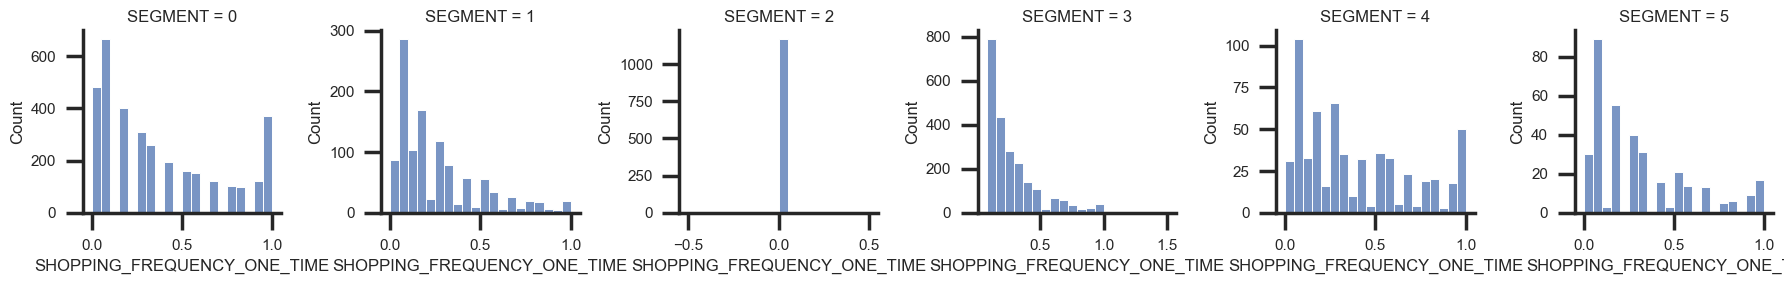

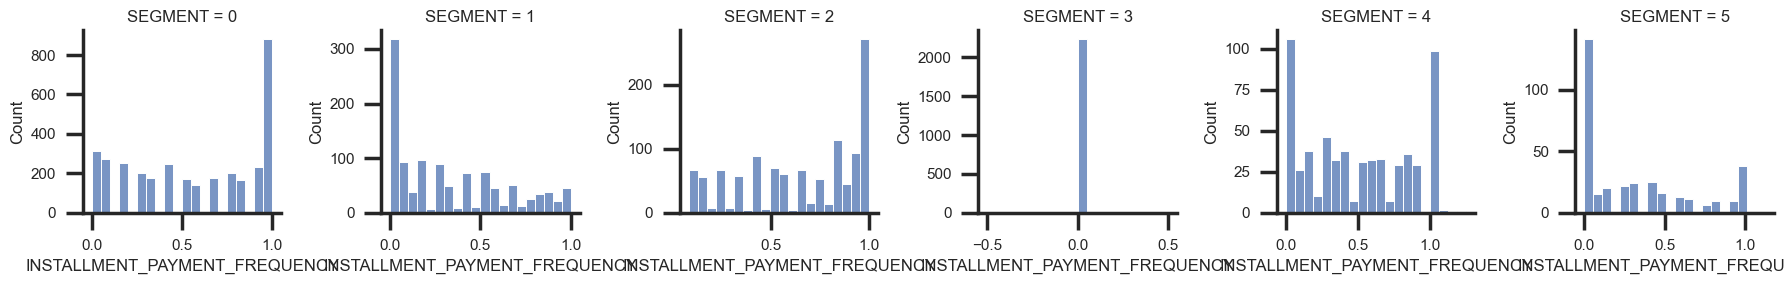

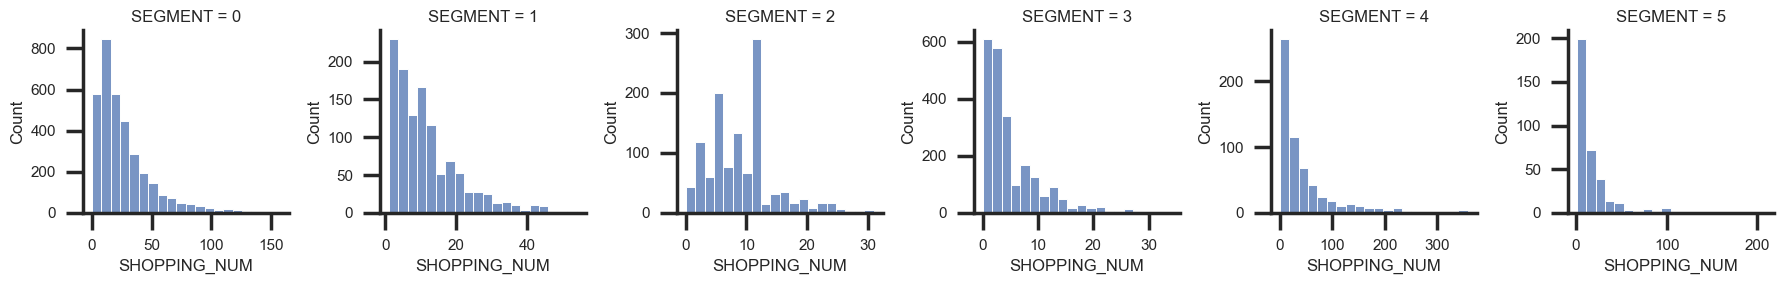

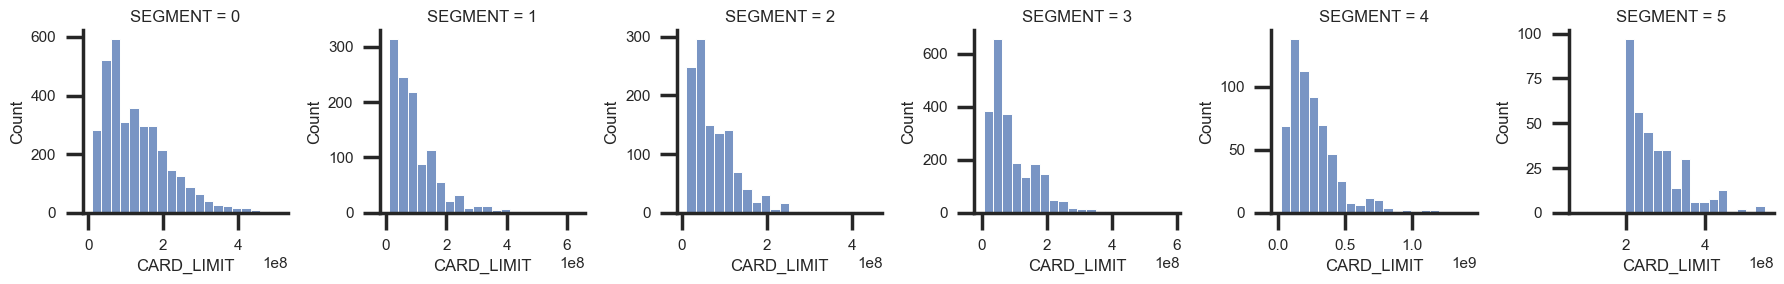

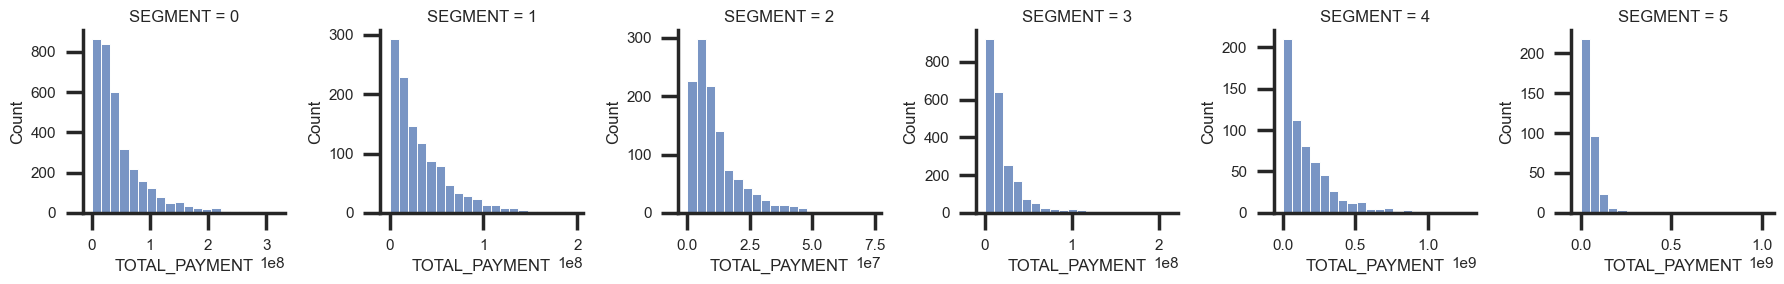

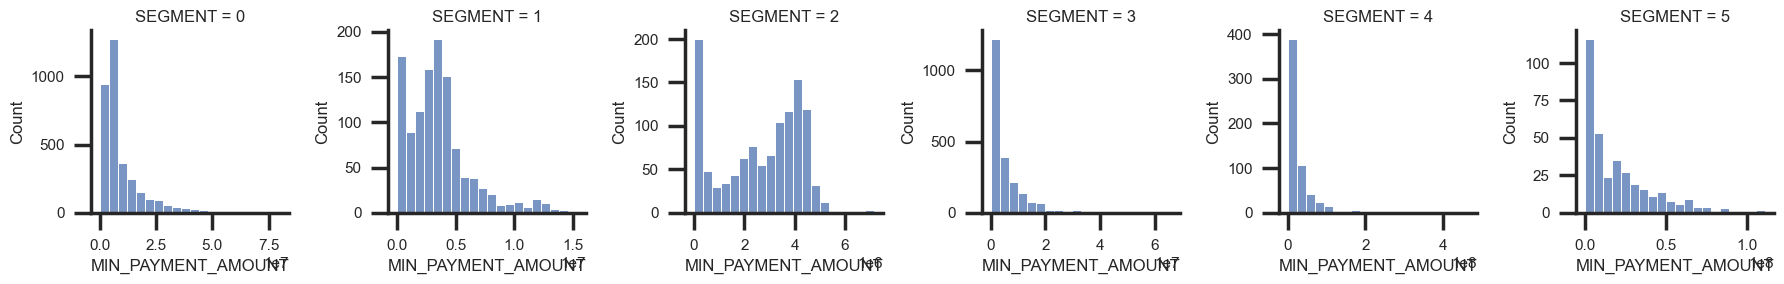

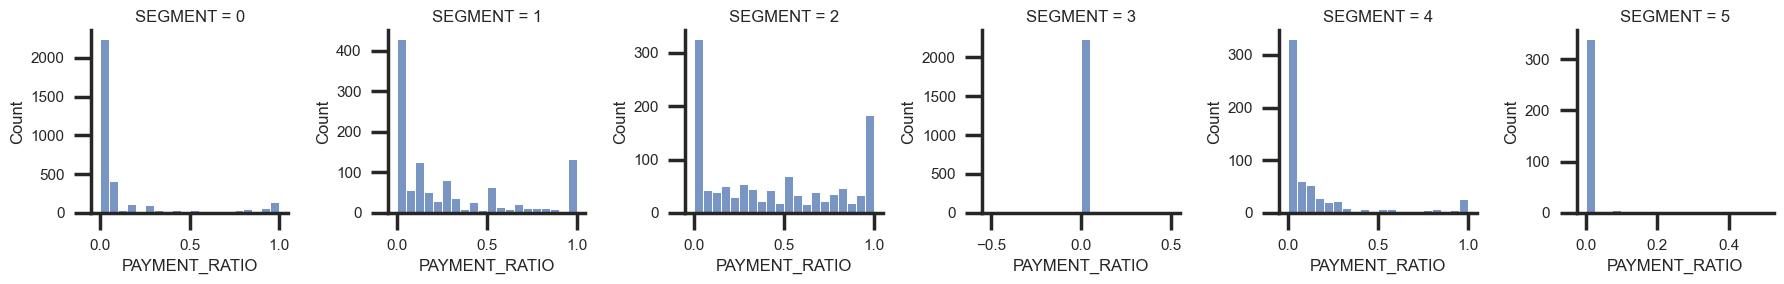

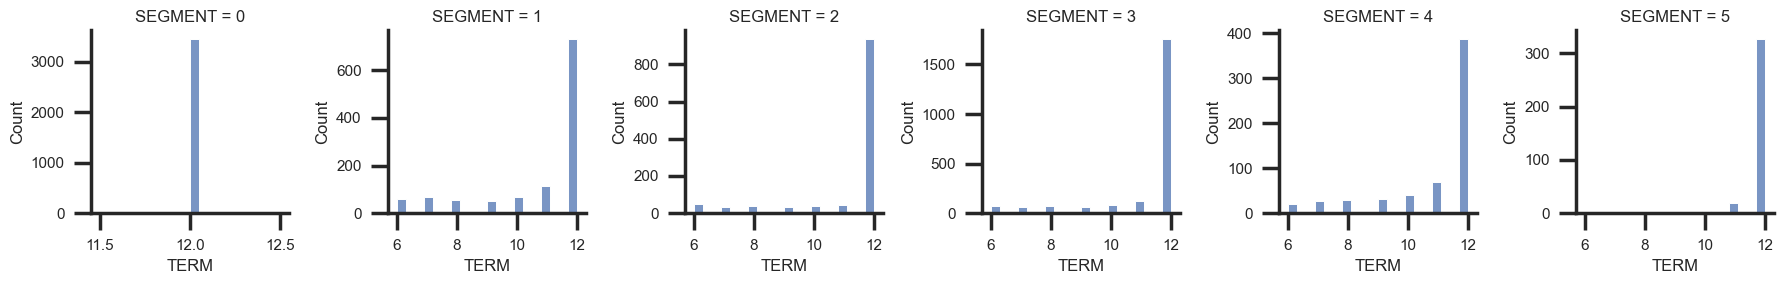

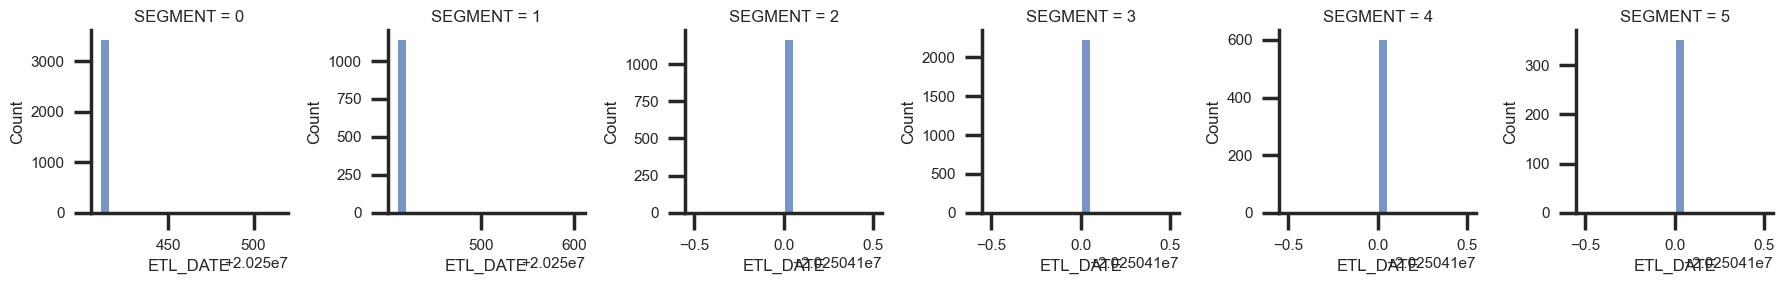

Number of cluster: 6


In [13]:
for c in result_df.columns:
    if c != 'SEGMENT':
        grid = sns.FacetGrid(result_df, col='SEGMENT', sharex=False, sharey=False)
        grid.map(sns.histplot, c, kde=False, bins=20)

plt.show()

num_clusters = len(result_df['SEGMENT'].unique())
print("Number of cluster:", num_clusters)

## VISUALIZE TO GET THE CORRECT SEGMENT

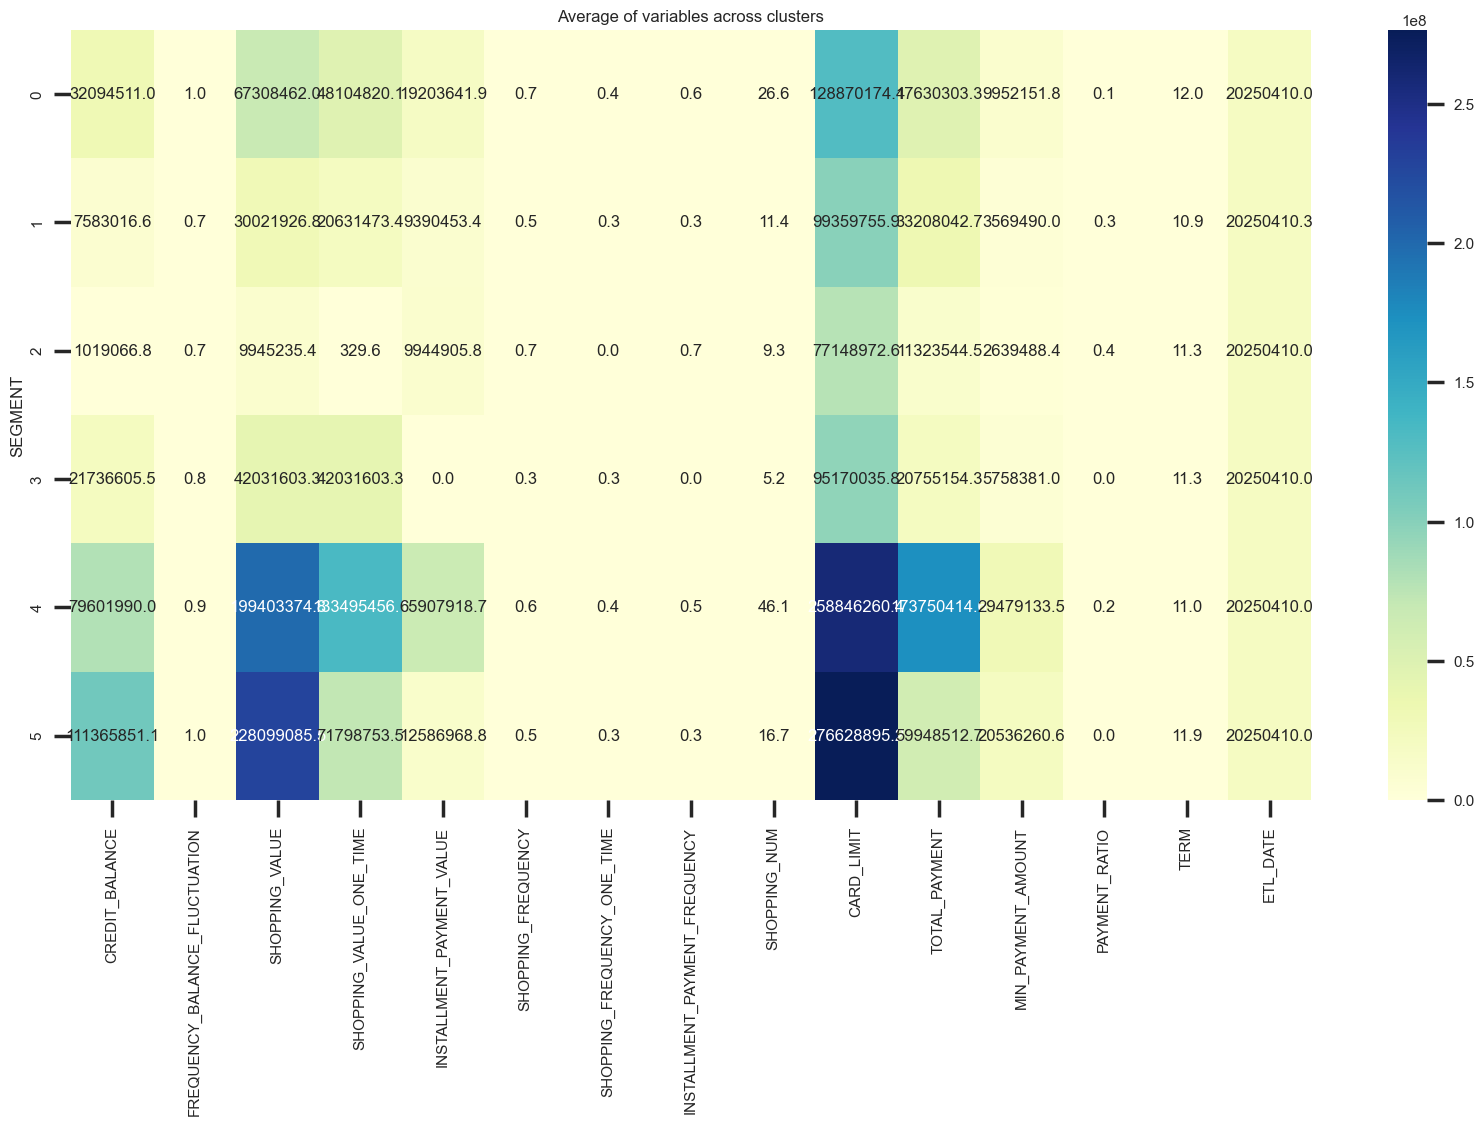

In [14]:
cluster_profile = (
    result_df
    .drop(columns=['CUS_ID'], errors='ignore')
    .select_dtypes(include=['number'])
    .groupby('SEGMENT')
    .mean()
)

plt.figure(figsize=(20,10))
sns.heatmap(cluster_profile, annot=True, fmt=".1f", cmap='YlGnBu')

plt.title("Average of variables across clusters")
plt.show()

## EDA NUMBER OF CUSTOMER FOR EACH SEGMENT

C:\Users\Surface\AppData\Local\Temp\ipykernel_16236\2439612063.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='SEGMENT', data=result_df, palette=random_colors)


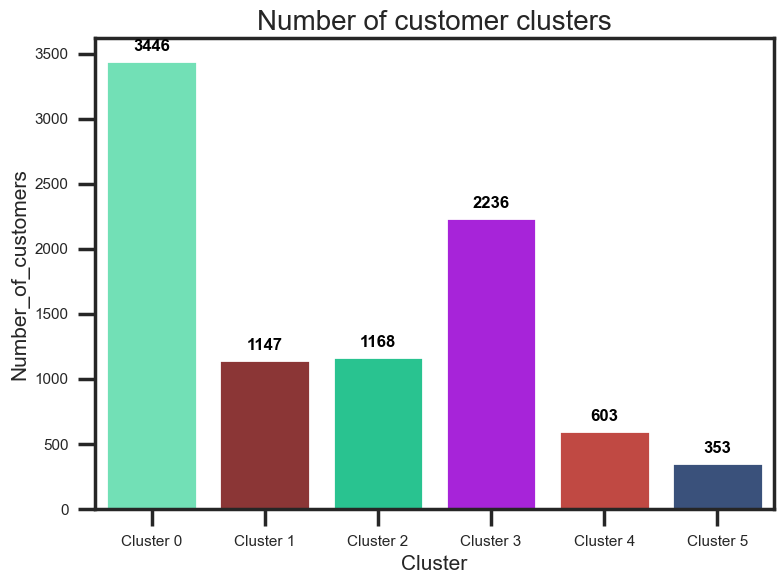

In [15]:
np.random.seed(42)
num_clusters = len(result_df['SEGMENT'].unique())
random_colors = [tuple(c) for c in np.random.rand(num_clusters, 3)]

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='SEGMENT', data=result_df, palette=random_colors)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black',
                fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.xticks(
    ticks=np.arange(num_clusters),
    labels=[f'Cluster {i}' for i in range(num_clusters)]
)

plt.title('Number of customer clusters', fontsize=20)
plt.xlabel('Cluster', fontsize=15)
plt.ylabel('Number_of_customers', fontsize=15)

plt.tight_layout()
plt.show()

## CHECK EACH SEGMENT DECRIPTION

In [16]:
np.random.seed(42)
for i in range(6):
    print(f'Cluster: {i}')
    cluster_data = result_df[result_df['SEGMENT'] == i]
    display(cluster_data.describe())

Cluster: 0


,CREDIT_BALANCE,FREQUENCY_BALANCE_FLUCTUATION,SHOPPING_VALUE,SHOPPING_VALUE_ONE_TIME,INSTALLMENT_PAYMENT_VALUE,SHOPPING_FREQUENCY,SHOPPING_FREQUENCY_ONE_TIME,INSTALLMENT_PAYMENT_FREQUENCY,SHOPPING_NUM,CARD_LIMIT,TOTAL_PAYMENT,MIN_PAYMENT_AMOUNT,PAYMENT_RATIO,TERM,ETL_DATE,SEGMENT
count,3.446000e+03,3446.0,3.446000e+03,3.446000e+03,3.446000e+03,3446.000000,3446.000000,3446.000000,3446.000000,3.446000e+03,3.446000e+03,3.446000e+03,3446.000000,3446.0,3.446000e+03,3446.0
mean,3.209451e+07,1.0,6.730846e+07,4.810482e+07,1.920364e+07,0.709784,0.365738,0.566913,26.566164,1.288702e+08,4.763030e+07,9.952152e+06,0.136630,12.0,2.025041e+07,0.0
std,4.264741e+07,0.0,6.152996e+07,5.587109e+07,2.242991e+07,0.326090,0.333288,0.363675,24.039448,8.750271e+07,4.775394e+07,1.171431e+07,0.276159,0.0,1.788676e+00,0.0
min,2.000000e+04,1.0,1.800000e+05,0.000000e+00,0.000000e+00,0.083333,0.000000,0.000000,0.000000,1.000000e+07,0.000000e+00,0.000000e+00,0.000000,12.0,2.025041e+07,0.0
25%,3.850000e+06,1.0,2.349000e+07,1.000000e+07,3.750000e+06,0.416667,0.083333,0.250000,11.000000,6.000000e+07,1.580000e+07,3.675000e+06,0.000000,12.0,2.025041e+07,0.0
50%,1.406250e+07,1.0,4.795000e+07,2.820000e+07,1.135000e+07,0.833333,0.250000,0.583333,19.000000,1.100000e+08,3.201250e+07,5.175000e+06,0.000000,12.0,2.025041e+07,0.0
75%,4.303125e+07,1.0,9.172500e+07,6.452375e+07,2.635000e+07,1.000000,0.583333,1.000000,35.000000,1.800000e+08,6.117500e+07,1.216875e+07,0.083333,12.0,2.025041e+07,0.0
max,2.933500e+08,1.0,3.919500e+08,3.553750e+08,1.395000e+08,1.000000,1.000000,1.000000,157.000000,5.100000e+08,3.166750e+08,8.010000e+07,1.000000,12.0,2.025052e+07,0.0


Cluster: 1


,CREDIT_BALANCE,FREQUENCY_BALANCE_FLUCTUATION,SHOPPING_VALUE,SHOPPING_VALUE_ONE_TIME,INSTALLMENT_PAYMENT_VALUE,SHOPPING_FREQUENCY,SHOPPING_FREQUENCY_ONE_TIME,INSTALLMENT_PAYMENT_FREQUENCY,SHOPPING_NUM,CARD_LIMIT,TOTAL_PAYMENT,MIN_PAYMENT_AMOUNT,PAYMENT_RATIO,TERM,ETL_DATE,SEGMENT
count,1.147000e+03,1147.000000,1.147000e+03,1.147000e+03,1.147000e+03,1147.000000,1147.000000,1147.000000,1147.000000,1.147000e+03,1.147000e+03,1.147000e+03,1147.000000,1147.000000,1.147000e+03,1147.0
mean,7.583017e+06,0.711619,3.002193e+07,2.063147e+07,9.390453e+06,0.493132,0.257822,0.323981,11.431561,9.935976e+07,3.320804e+07,3.569490e+06,0.280510,10.854403,2.025041e+07,1.0
std,9.032239e+06,0.242663,2.318149e+07,2.159308e+07,1.257415e+07,0.307113,0.229480,0.313046,9.531127,8.171556e+07,3.243718e+07,2.745299e+06,0.340356,1.875414,8.013919e+00,0.0
min,0.000000e+00,0.000000,4.000000e+05,-1.005000e+07,0.000000e+00,0.083333,0.000000,0.000000,1.000000,1.000000e+07,0.000000e+00,0.000000e+00,0.000000,6.000000,2.025041e+07,1.0
25%,1.175000e+06,0.545455,1.158750e+07,4.250000e+06,0.000000e+00,0.200000,0.083333,0.000000,4.000000,4.000000e+07,9.425000e+06,1.746250e+06,0.000000,10.000000,2.025041e+07,1.0
50%,3.425000e+06,0.800000,2.475000e+07,1.345000e+07,5.175000e+06,0.500000,0.166667,0.250000,9.000000,8.000000e+07,2.260000e+07,3.225000e+06,0.125000,12.000000,2.025041e+07,1.0
75%,1.101250e+07,0.909091,4.245000e+07,2.831250e+07,1.233750e+07,0.750000,0.333333,0.555556,15.500000,1.300000e+08,4.770000e+07,4.450000e+06,0.500000,12.000000,2.025041e+07,1.0
max,4.670000e+07,1.000000,1.259750e+08,1.259750e+08,7.272500e+07,1.000000,1.000000,1.000000,54.000000,6.300000e+08,1.960500e+08,1.532500e+07,1.000000,12.000000,2.025060e+07,1.0


Cluster: 2


...

,CREDIT_BALANCE,FREQUENCY_BALANCE_FLUCTUATION,SHOPPING_VALUE,SHOPPING_VALUE_ONE_TIME,INSTALLMENT_PAYMENT_VALUE,SHOPPING_FREQUENCY,SHOPPING_FREQUENCY_ONE_TIME,INSTALLMENT_PAYMENT_FREQUENCY,SHOPPING_NUM,CARD_LIMIT,TOTAL_PAYMENT,MIN_PAYMENT_AMOUNT,PAYMENT_RATIO,TERM,ETL_DATE,SEGMENT
count,2.236000e+03,2236.000000,2.236000e+03,2.236000e+03,2236.0,2236.000000,2236.000000,2236.0,2236.000000,2.236000e+03,2.236000e+03,2.236000e+03,2236.0,2236.000000,2236.0,2236.0
mean,2.173661e+07,0.846306,4.203160e+07,4.203160e+07,0.0,0.265879,0.265879,0.0,5.173971,9.517004e+07,2.075515e+07,5.758381e+06,0.0,11.310376,20250410.0,3.0
std,3.772468e+07,0.273137,5.236304e+07,5.236304e+07,0.0,0.216007,0.216007,0.0,5.318043,7.371970e+07,2.457802e+07,8.130804e+06,0.0,1.561076,0.0,0.0
min,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.083333,0.083333,0.0,0.000000,5.475000e+06,0.000000e+00,0.000000e+00,0.0,6.000000,20250410.0,3.0
25%,8.900000e+05,0.818182,7.511250e+06,7.511250e+06,0.0,0.083333,0.083333,0.0,1.000000,4.000000e+07,6.975000e+06,8.450000e+05,0.0,12.000000,20250410.0,3.0
50%,4.052500e+06,1.000000,2.355500e+07,2.355500e+07,0.0,0.166667,0.166667,0.0,3.000000,8.000000e+07,1.318750e+07,2.661250e+06,0.0,12.000000,20250410.0,3.0
75%,2.633750e+07,1.000000,5.572125e+07,5.572125e+07,0.0,0.333333,0.333333,0.0,7.000000,1.300000e+08,2.515625e+07,7.300000e+06,0.0,12.000000,20250410.0,3.0
max,2.895250e+08,1.000000,4.156200e+08,4.156200e+08,0.0,1.500000,1.500000,0.0,34.000000,5.800000e+08,2.123500e+08,6.605000e+07,0.0,12.000000,20250410.0,3.0


Cluster: 4


,CREDIT_BALANCE,FREQUENCY_BALANCE_FLUCTUATION,SHOPPING_VALUE,SHOPPING_VALUE_ONE_TIME,INSTALLMENT_PAYMENT_VALUE,SHOPPING_FREQUENCY,SHOPPING_FREQUENCY_ONE_TIME,INSTALLMENT_PAYMENT_FREQUENCY,SHOPPING_NUM,CARD_LIMIT,TOTAL_PAYMENT,MIN_PAYMENT_AMOUNT,PAYMENT_RATIO,TERM,ETL_DATE,SEGMENT
count,6.030000e+02,603.000000,6.030000e+02,6.030000e+02,6.030000e+02,603.000000,603.000000,603.000000,603.000000,6.030000e+02,6.030000e+02,6.030000e+02,603.000000,603.000000,603.0,603.0
mean,7.960199e+07,0.884341,1.994034e+08,1.334955e+08,6.590792e+07,0.585050,0.385631,0.490331,46.124378,2.588463e+08,1.737504e+08,2.947913e+07,0.151844,10.978441,20250410.0,4.0
std,7.511034e+07,0.178560,1.732859e+08,1.615330e+08,8.470536e+07,0.346176,0.305848,0.361168,59.637772,1.930617e+08,1.880191e+08,4.569302e+07,0.268165,1.706310,0.0,0.0
min,0.000000e+00,0.000000,2.475000e+06,-1.500000e+07,0.000000e+00,0.083333,0.000000,0.000000,0.000000,2.000000e+07,0.000000e+00,0.000000e+00,0.000000,6.000000,20250410.0,4.0
25%,2.458750e+07,0.818182,8.732500e+07,2.608000e+07,3.812500e+06,0.250000,0.125000,0.166667,10.000000,1.300000e+08,3.992500e+07,4.725000e+06,0.000000,11.000000,20250410.0,4.0
50%,5.697500e+07,1.000000,1.447650e+08,8.432500e+07,3.077500e+07,0.583333,0.272727,0.454545,23.000000,2.000000e+08,1.159750e+08,1.612500e+07,0.000000,12.000000,20250410.0,4.0
75%,1.108625e+08,1.000000,2.567375e+08,1.722750e+08,9.903750e+07,1.000000,0.583333,0.833333,55.000000,3.395525e+08,2.423000e+08,3.350000e+07,0.166667,12.000000,20250410.0,4.0
max,4.760750e+08,1.000000,1.239925e+09,1.181775e+09,5.625000e+08,1.000000,1.000000,1.250000,358.000000,1.410000e+09,1.268025e+09,4.655250e+08,1.000000,12.000000,20250410.0,4.0


Cluster: 5


,CREDIT_BALANCE,FREQUENCY_BALANCE_FLUCTUATION,SHOPPING_VALUE,SHOPPING_VALUE_ONE_TIME,INSTALLMENT_PAYMENT_VALUE,SHOPPING_FREQUENCY,SHOPPING_FREQUENCY_ONE_TIME,INSTALLMENT_PAYMENT_FREQUENCY,SHOPPING_NUM,CARD_LIMIT,TOTAL_PAYMENT,MIN_PAYMENT_AMOUNT,PAYMENT_RATIO,TERM,ETL_DATE,SEGMENT
count,3.530000e+02,353.000000,3.530000e+02,3.530000e+02,3.530000e+02,353.000000,353.000000,353.000000,353.000000,3.530000e+02,3.530000e+02,3.530000e+02,353.000000,353.000000,353.0,353.0
mean,1.113659e+08,0.981046,2.280991e+08,7.179875e+07,1.258697e+07,0.490006,0.303221,0.318811,16.677054,2.766289e+08,5.994851e+07,2.053626e+07,0.006887,11.869688,20250410.0,5.0
std,7.440635e+07,0.093106,6.176257e+07,6.044434e+07,2.286590e+07,0.326742,0.274742,0.354734,22.295866,7.490313e+07,7.887686e+07,2.119791e+07,0.042205,0.612386,0.0,0.0
min,4.325000e+06,0.181818,6.597500e+07,2.800000e+05,0.000000e+00,0.083333,0.000000,0.000000,1.000000,8.000000e+07,0.000000e+00,0.000000e+00,0.000000,6.000000,20250410.0,5.0
25%,4.972500e+07,1.000000,1.731591e+08,2.254500e+07,0.000000e+00,0.166667,0.083333,0.000000,5.000000,2.100000e+08,2.722500e+07,4.355000e+06,0.000000,12.000000,20250410.0,5.0
50%,9.677500e+07,1.000000,2.061418e+08,5.301000e+07,2.500000e+06,0.416667,0.181818,0.181818,9.000000,2.500000e+08,4.332500e+07,1.257750e+07,0.000000,12.000000,20250410.0,5.0
75%,1.576500e+08,1.000000,2.556158e+08,1.155550e+08,1.250000e+07,0.750000,0.416667,0.583333,20.000000,3.100000e+08,6.380000e+07,2.955000e+07,0.000000,12.000000,20250410.0,5.0
max,3.814500e+08,1.000000,4.535118e+08,2.644700e+08,1.274000e+08,1.000000,1.000000,1.125000,208.000000,5.500000e+08,1.015675e+09,1.110250e+08,0.500000,12.000000,20250410.0,5.0


In [17]:
cluster_profile = result_df.groupby('SEGMENT').mean(numeric_only=True)

from sklearn.preprocessing import MinMaxScaler

scaler2 = MinMaxScaler()
cluster_scaled = pd.DataFrame(
    scaler2.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

# FIT AND MAP FOR EACH CLUSTER TO FIT SEGMENT_NAME

In [18]:
segment_prototype = {

    "KH VIP": {
        "SHOPPING_VALUE": 1.0,
        "SHOPPING_FREQUENCY": 0.9,
        "SHOPPING_NUM": 1.0,
        "CARD_LIMIT": 1.0,
        "CREDIT_BALANCE": 0.9
    },

    "KH cận VIP": {
        "SHOPPING_VALUE": 0.8,
        "SHOPPING_FREQUENCY": 0.75,
        "SHOPPING_NUM": 0.8,
        "CARD_LIMIT": 0.85,
        "CREDIT_BALANCE": 0.7
    },

    "KH chi tiêu đều": {
        "SHOPPING_VALUE": 0.6,
        "SHOPPING_FREQUENCY": 1.0,
        "SHOPPING_NUM": 0.7,
        "CARD_LIMIT": 0.5,
        "CREDIT_BALANCE": 0.5
    },

    "KH phổ thông tiềm năng": {
        "SHOPPING_VALUE": 0.5,
        "SHOPPING_FREQUENCY": 0.5,
        "SHOPPING_NUM": 0.5,
        "CARD_LIMIT": 0.5,
        "CREDIT_BALANCE": 0.5
    },

    "KH nhỏ lẻ": {
        "SHOPPING_VALUE": 0.3,
        "SHOPPING_FREQUENCY": 0.3,
        "SHOPPING_NUM": 0.3,
        "CARD_LIMIT": 0.3,
        "CREDIT_BALANCE": 0.3
    },

    "KH ngủ đông": {
        "SHOPPING_VALUE": 0.01,
        "SHOPPING_FREQUENCY": 0.01,
        "SHOPPING_NUM": 0.01,
        "CARD_LIMIT": 0.05,
        "CREDIT_BALANCE": 0.05
    }
}

In [19]:
import numpy as np

def score_cluster(cluster_row, prototype):
    score = 0
    for feature, expected in prototype.items():
        if feature in cluster_row:
            score += 1 - abs(cluster_row[feature] - expected)
    return score

cluster_to_segment = {}
used_segments = set()

for cluster_id, row in cluster_scaled.iterrows():
    best_segment = None
    best_score = -1
    
    for segment, proto in segment_prototype.items():
        if segment in used_segments:
            continue
            
        s = score_cluster(row, proto)
        
        if s > best_score:
            best_score = s
            best_segment = segment
    
    cluster_to_segment[cluster_id] = best_segment
    used_segments.add(best_segment)

In [20]:
segment_df = pd.DataFrame([
    {"SEGMENT": k, "SEGMENT_NAME": v}
    for k, v in cluster_to_segment.items()
])

In [21]:
map_des = {
    "KH chi tiêu đều": "Khách hàng có tần suất giao dịch khá thường xuyên với mức chi tiêu trung bình. Tuy nhiên tỷ lệ thanh toán chưa cao, cho thấy khách hàng thường duy trì dư nợ. Có thể áp dụng chương trình tích điểm, hoàn tiền hoặc nhắc nhở thanh toán tự động để cải thiện tỷ lệ thanh toán.",
    "KH nhỏ lẻ": "Khách hàng có giá trị giao dịch thấp và tần suất sử dụng thẻ không cao. Chủ yếu phát sinh các giao dịch nhỏ như siêu thị, cửa hàng tiện lợi hoặc chi tiêu cá nhân. Có thể thu hút bằng ưu đãi trả góp 0%, miễn phí thường niên, hoặc các chương trình khuyến mãi dùng thử dịch vụ.",
    "KH cận VIP": "Nhóm khách hàng có mức chi tiêu và số dư thẻ cao, tần suất giao dịch lớn. Nhu cầu mua sắm cả trả góp và một lần đều cao, gần đạt nhóm VIP. Có thể tiếp thị các chương trình nâng hạng như ưu đãi du lịch, lounge sân bay, hoàn tiền cao cấp hoặc combo dịch vụ.",
    "KH ngủ đông": "Khách hàng ít hoặc gần như không phát sinh giao dịch trong thời gian dài. Tần suất sử dụng thẻ thấp, có dấu hiệu không còn hoạt động. Cần triển khai các chiến dịch tái kích hoạt như mini-campaign khởi động lại thẻ, khảo sát lý do ngừng sử dụng hoặc ưu đãi quay lại.",
    "KH phổ thông tiềm năng": "Khách hàng có mức chi tiêu khá ổn định, số lần giao dịch nhiều và có sử dụng cả mua sắm một lần lẫn trả góp. Tỷ lệ thanh toán tương đối ổn định. Đây là nhóm có tiềm năng upsell thông qua các chương trình hoàn tiền, tích điểm hoặc tăng hạn mức tín dụng.",
    "KH VIP": "Nhóm khách hàng có giá trị chi tiêu rất cao, sử dụng thẻ thường xuyên cho nhiều mục đích khác nhau. Các giao dịch mua một lần và trả góp đều lớn. Phù hợp với các chương trình ưu đãi cao cấp như du lịch, lounge, spa, hoàn tiền cao cấp, nâng hạn mức và nâng hạng membership."
}
segment_df["SEGMENT_DESCRIPTION"] = segment_df["SEGMENT_NAME"].map(map_des)

In [22]:
segment_df

,SEGMENT,SEGMENT_NAME,SEGMENT_DESCRIPTION
0,0,KH chi tiêu đều,Khách hàng có tần suất giao dịch khá thường xu...
1,1,KH ngủ đông,Khách hàng ít hoặc gần như không phát sinh gia...
2,2,KH nhỏ lẻ,Khách hàng có giá trị giao dịch thấp và tần su...
3,3,KH phổ thông tiềm năng,"Khách hàng có mức chi tiêu khá ổn định, số lần..."
4,4,KH cận VIP,Nhóm khách hàng có mức chi tiêu và số dư thẻ c...
5,5,KH VIP,"Nhóm khách hàng có giá trị chi tiêu rất cao, s..."


## EXPORT TO DIM TABLE

In [23]:
dim_customer_segment = segment_df[['SEGMENT', 'SEGMENT_NAME', 'SEGMENT_DESCRIPTION']]

segment_df.to_csv(r"D:\Đồ án\Recommentation_test\Data\DIM_CUSTOMER_SEGMENT.csv", index=False, encoding='utf-8-sig')

In [24]:
dim_customer_segment

,SEGMENT,SEGMENT_NAME,SEGMENT_DESCRIPTION
0,0,KH chi tiêu đều,Khách hàng có tần suất giao dịch khá thường xu...
1,1,KH ngủ đông,Khách hàng ít hoặc gần như không phát sinh gia...
2,2,KH nhỏ lẻ,Khách hàng có giá trị giao dịch thấp và tần su...
3,3,KH phổ thông tiềm năng,"Khách hàng có mức chi tiêu khá ổn định, số lần..."
4,4,KH cận VIP,Nhóm khách hàng có mức chi tiêu và số dư thẻ c...
5,5,KH VIP,"Nhóm khách hàng có giá trị chi tiêu rất cao, s..."


In [25]:
os.makedirs(r'D:\Đồ án\Recommentation_test', exist_ok=True)
result_df.to_csv(r'D:\Đồ án\Recommentation_test\Data\CREDIT_USE_CUSTOMER.csv', index=False)


In [26]:
os.makedirs(r'D:\Đồ án\Recommentation_test\save_model', exist_ok=True)
joblib.dump(GMM, r'D:\Đồ án\Recommentation_test\save_model\gmm_model.pkl')
joblib.dump(scaler, r'D:\Đồ án\Recommentation_test\save_model\scaler.pkl')

['D:\\Đồ án\\Recommentation_test\\save_model\\scaler.pkl']